In [107]:
import numpy as np 
from scipy import sparse 
from matplotlib import pyplot as plt
from matplotlib import animation
from time import time
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from tqdm import tqdm


## Solve Explicit

In [98]:
def explicit_heat_solver_2d(nu, u0, x_span, y_span, tf, nx, ny, nt):

    # define space and time domains
    x_vals, dx = np.linspace(*x_span, nx+1, retstep=True)
    y_vals, dy = np.linspace(*y_span, ny+1, retstep=True)
    t_vals, dt = np.linspace(0, tf, nt+1, retstep=True)
    X, Y = np.meshgrid(x_vals, y_vals)

    # compute CFL values
    lam_x = -nu * dt / dx**4
    lam_y = -nu * dt / dy**4

    # compute the initial state
    U_init = np.array(
        [[u0(X[i, j], Y[i, j]) for i in range(X.shape[0])] for j in range(X.shape[1])]
    )
    
    # build stiffness matrix
    T = sparse.diags(
        [lam_x, -4*lam_x, 1 - 6*lam_x - 6 * lam_y, -4*lam_x, lam_x],
        [-2, -1, 0, 1, 2], 
        shape=(nx-3, nx-3)
    )
    A = sparse.block_diag([T] * (ny-3))
    A.setdiag(-4 * lam_y, -(nx-3))
    A.setdiag(-4 * lam_y, nx-3)
    
    A.setdiag(lam_y, -(2 * ny-6))
    A.setdiag(lam_y, 2 * ny-6)

    # initialize solution matrix -- homogenous Dirichlet BCs
    U = np.zeros((nt+1, nx+1, ny+1))
    sl = np.s_[2:-2]                    # interior slice 
    U[0, sl, sl] = U_init[sl, sl]       # set initial state on interior

    start = time()
    # solver loop 
    for t in range(1, nt+1):
        # this only works for homogenous Dirichlet BCs
        # if non-homoegenous, there should be an additive term on the right side
        U[t, sl, sl] = (A @ U[t-1, sl, sl].flatten()).reshape((nx-3, ny-3))

    return U, X, Y, t_vals, time() - start

In [108]:
# model parameters 
nu = 1.             # diffusion coefficient
x0, xf = 0, 1       # space domain (x)
y0, yf = 0, 1       # space domain (y)
tf = 0.25           # time domain
def u0(x, y):       # initial state
    return (
        np.sin(np.pi * (x - x0) / (xf - x0)) * 
        np.sin(np.pi * (y - y0) / (yf - y0))
    )

# system parameters 
nx = 50 
ny = 50
nt = 100 

# test solver 
U_explicit, X, Y, t_vals, end_time = explicit_heat_solver_2d(nu, u0, (x0, xf), (y0, yf), tf, nx, ny, nt)

In [109]:
def my_truth(X, Y, t):
    spatial_part = np.sin(np.pi * X) * np.sin(np.pi * Y)
    temporal_decay = np.exp(-2 * nu * (np.pi**4) * t)
    return spatial_part * temporal_decay

Ts = np.array([i for i in range(10,60,10)])

explicit_time = []
explicit_converge = []

for t in Ts:
    solve = explicit_heat_solver_2d(nu, u0, (x0, xf), (y0, yf), tf, t, t, t)
    explicit_time.append(solve[-1])
    explicit_converge.append(np.sqrt(1/nx * 1/ny) * np.linalg.norm(solve[0][-1] - my_truth(solve[1], solve[2], .25)))


## Solve Crank-Nicolson

In [135]:
def crank_nicolson_heat_solver_2d(nu, u0, x_span, y_span, tf, nx, ny, nt):
    # define space and time domains
    x_vals, dx = np.linspace(*x_span, nx+1, retstep=True)
    y_vals, dy = np.linspace(*y_span, ny+1, retstep=True)
    t_vals, dt = np.linspace(0, tf, nt+1, retstep=True)
    X, Y = np.meshgrid(x_vals, y_vals)

    # compute CFL values
    lam_x = nu * dt / dx**4
    lam_y = nu * dt / dy**4

    # compute the initial state
    U_init = np.array(
        [[u0(X[i, j], Y[i, j]) for i in range(X.shape[0])] for j in range(X.shape[1])]
    )
    
    # construct stiffness matrices
    # 1. Define Interior Dimensions
    W = nx - 3  # Based on sl = np.s_[2:-2]
    H = ny - 3
    
    # 2. Build the 1D Fourth-Derivative Operators (Stencil: [1, -4, 6, -4, 1])
    # Note: We don't multiply by nu*dt here; we do it in the next step
    Dx4 = sparse.diags([1, -4, 6, -4, 1], [-2, -1, 0, 1, 2], shape=(W, W))
    Dy4 = sparse.diags([1, -4, 6, -4, 1], [-2, -1, 0, 1, 2], shape=(H, H))
    
    # 3. Build the 2D Laplacian using Kronecker Sum
    Ix = sparse.eye(W)
    Iy = sparse.eye(H)
    # L_2D = (u_xxxx + u_yyyy)
    L_2D = (sparse.kron(Iy, Dx4) + sparse.kron(Dy4, Ix))
    
    # 4. Apply Physics and Time-stepping (nu and dt)
    # P = I + (dt*nu/2) * L_2D
    # Q = I - (dt*nu/2) * L_2D
    I_full = sparse.eye(W * H)
    P = (I_full + (dt * nu / 2.0) * L_2D).tocsr()
    Q = (I_full - (dt * nu / 2.0) * L_2D).tocsr()

    start = time()
    U = np.zeros((nt+1, nx+1, ny+1))
    sl = np.s_[2:-2]                    # interior slice 
    U[0, sl, sl] = U_init[sl, sl] 
    # ... (Solver loop) ...
    for t in range(1, nt+1):
        b = Q @ U[t-1, sl, sl].flatten()
        U[t, sl, sl] = sparse.linalg.spsolve(P, b).reshape((H, W)) # Note H, W order

    return U, X, Y, t_vals, time() - start

In [133]:
def crank_nicolson_heat_solver_2d(nu, u0, x_span, y_span, tf, nx, ny, nt):
    # define space and time domains
    x_vals, dx = np.linspace(*x_span, nx+1, retstep=True)
    y_vals, dy = np.linspace(*y_span, ny+1, retstep=True)
    t_vals, dt = np.linspace(0, tf, nt+1, retstep=True)
    X, Y = np.meshgrid(x_vals, y_vals)

    # compute CFL values
    lam_x = nu * dt / dx**4
    lam_y = nu * dt / dy**4

    # compute the initial state
    U_init = np.array(
        [[u0(X[i, j], Y[i, j]) for i in range(X.shape[0])] for j in range(X.shape[1])]
    )
    
    # construct stiffness matrices
    # Q (explicit side)
    T_Q = sparse.diags(
        [-lam_x/2, 2*lam_x, 1 - 3*lam_x - 3 * lam_y, 2*lam_x, -lam_x/2],
        [-2, -1, 0, 1, 2], 
        shape=(nx-3, nx-3)
    )
    
    Q = sparse.block_diag([T_Q] * (ny-3))
    Q.setdiag(2 * lam_y, -(nx-3))
    Q.setdiag(2 * lam_y, nx-3)
    
    Q.setdiag(-lam_y/2., -(2 * nx-6))
    Q.setdiag(-lam_y/2., 2 * nx-6)
    Q = Q.tocsr()
    
    # P (implicit side)
    T_P = sparse.diags(
        [lam_x/2, -2*lam_x, 1 + 3*lam_x + 3 * lam_y, -2*lam_x, lam_x/2],
        [-2, -1, 0, 1, 2], 
        shape=(nx-3, nx-3)
    )
    
    
    P = sparse.block_diag([T_P] * (ny-3))
    P.setdiag(-2 * lam_y, -(nx-3))
    P.setdiag(-2 * lam_y, nx-3)
    
    P.setdiag(lam_y/2., -(2*nx-6))
    P.setdiag(lam_y/2., 2*nx-6)
    P = P.tocsr()

    # initialize solution matrix -- homogenous Dirichlet BCs
    U = np.zeros((nt+1, nx+1, ny+1))
    sl = np.s_[2:-2]                    # interior slice 
    U[0, sl, sl] = U_init[sl, sl]       # set initial state on interior

    start = time()
    # solver loop 
    for t in range(1, nt+1):
        U[t, sl, sl] = (sparse.linalg.spsolve(P, Q @ U[t-1, sl, sl].flatten())).reshape((nx-3, ny-3))

    return U, X, Y, t_vals, time() - start

In [136]:
U_crank, X, Y, t_vals, end_time = crank_nicolson_heat_solver_2d(nu, u0, (x0, xf), (y0, yf), tf, nx, ny, nt)

In [127]:
crank_time = []
crank_converge = []

for t in Ts:
    solve = crank_nicolson_heat_solver_2d(nu, u0, (x0, xf), (y0, yf), tf, t, t, t)
    crank_time.append(solve[-1])
    crank_converge.append(np.sqrt(1/nx * 1/ny) * np.linalg.norm(solve[0][-1] - my_truth(solve[1], solve[2], .25)))


## Solve ETD

In [110]:
def exponential_heat_solver_2d(nu, u0, x_span, y_span, tf, nx, ny, nt):
    # define space and time domains
    x_vals, dx = np.linspace(*x_span, nx+1, retstep=True)
    y_vals, dy = np.linspace(*y_span, ny+1, retstep=True)
    t_vals, dt = np.linspace(0, tf, nt+1, retstep=True)
    X, Y = np.meshgrid(x_vals, y_vals)

    # pre-compute these values
    dx4_inv = 1. / dx**4
    dy4_inv = 1. / dy**4

    # compute the initial state
    U_init = np.array(
        [[u0(X[i, j], Y[i, j]) for i in range(X.shape[0])] for j in range(X.shape[1])]
    )

    # define differential operator
    T = sparse.diags(
        [dx4_inv, -4*dx4_inv, 6*dx4_inv, -4*dx4_inv, dx4_inv],
        [-2, -1, 0, 1, 2], 
        shape=(nx-3, nx-3)
    )
    
    
    L = sparse.block_diag([T] * (ny-3))
    L.setdiag(-4 * dy4_inv, -(ny-3))
    L.setdiag(-4 * dy4_inv, ny-3)
    
    L.setdiag(dy4_inv, -(2*ny-6))
    L.setdiag(dy4_inv, 2*ny-6)
    # L = L.toarray()
    L = L.tocsr()

    # exponentiate the linear operator via diagonalization
    # lam, V = sparse.linalg.eigs(dt * nu * L, k=(nx-1)*(ny-1) - 2)
    # lam, V = np.linalg.eig(dt * nu * L)
    # exp_operator = V @ np.diag(np.exp(lam)) @ np.linalg.inv(V)
    exp_operator = sparse.linalg.expm(dt * nu * L)

    # initialize solution matrix -- homogenous Dirichlet BCs
    U = np.zeros((nt+1, nx+1, ny+1))
    sl = np.s_[2:-2]                    # interior slice 
    U[0, sl, sl] = U_init[sl, sl]       # set initial state on interior

    start = time()
    # solver loop
    for t in range(1, nt+1):
        U[t, sl, sl] = (exp_operator @ U[t-1, sl, sl].flatten()).reshape((nx-3, ny-3))

    return U, X, Y, t_vals, time() - start

In [111]:
U_edt, X, Y, t_vals, end_time = exponential_heat_solver_2d(nu, u0, (x0, xf), (y0, yf), tf, nx, ny, nt)

In [124]:
U_edt[-1]

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0., nan, ..., nan,  0.,  0.],
       ...,
       [ 0.,  0., nan, ..., nan,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

In [ ]:
edt_time = []
edt_converge = []

for t in tqdm(Ts):
    solve = exponential_heat_solver_2d(nu, u0, (x0, xf), (y0, yf), tf, t, t, t)
    edt_time.append(solve[-1])
    edt_converge.append(np.sqrt(1/nx * 1/ny) * np.linalg.norm(solve[0][-1] - my_truth(solve[1], solve[2], .25)))

  0%|          | 0/5 [00:00<?, ?it/s]/Users/mckayladavis/opt/anaconda3/envs/acme/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:412: SparseEfficiencyWarning: splu converted its input to CSC format
  warn('splu converted its input to CSC format', SparseEfficiencyWarning)
/Users/mckayladavis/opt/anaconda3/envs/acme/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:302: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  warn('spsolve is more efficient when sparse b '
100%|██████████| 5/5 [06:04<00:00, 72.99s/it] 


## Solve ADI

In [119]:
def ADI_Solver(alpha, h_x, h_y, h_t, plot = False, filename = 'adi_solution.mp4', initial = None, truth = None):
    '''
    Solves the 2-d heat equation with homogeneous boundary conditions using the alternating direction implicit method.
    
    INPUTS:
    alpha (float): a from the heat equation
    h_x (float): the step size for x direction
    h_x (float): the step size for y direction
    h_t (float): the step size for time
    plot(bool): whether or not you would like an animation drawn for your solution
    filename (str): the filename for the animation
    initial (func): a function taking in X, Y representing the initial condition of the solution
    truth (func): a function taking in X,Y representing the true solution at the final time step
    
    RETURNS:
    U (np.array): solution for u at each timestep
    norm (float): the error
    time (float): the time it took to solve the system
    
    '''
    # Initialize intial condition if needed
    if initial == None:
        initial = lambda x,y: 1 * np.sin(np.pi * x) * 1 * np.sin(np.pi * y)
        truth = lambda X, Y, t: np.exp(-2 * np.pi**2 * alpha * t) * np.sin(np.pi * X) * np.sin(np.pi * Y)
    
    # Define mesh
    x = np.linspace(0,1,int(1/h_x) + 1)
    y = np.linspace(0,1,int(1/h_y) + 1)
    t_vals = np.linspace(0,.25,int(.25/h_t) + 1)

    X,Y = np.meshgrid(x,y)

    # Derive ADI matrices
    A_1 = alpha/(h_x**4) * (np.diag(np.ones_like(x)[2:], k = -2) +\
                            np.diag(np.ones_like(x)[1:] * -4, k = -1) +\
                            np.diag(np.ones_like(x) * 6, k = 0) +\
                            np.diag(np.ones_like(x)[1:] * -4, k = 1) +\
                            np.diag(np.ones_like(x)[2:], k = 2))
    
    A_2 = alpha/(h_y**4) * (np.diag(np.ones_like(y)[2:], k = -2) +\
                            np.diag(np.ones_like(y)[1:] * -4, k = -1) +\
                            np.diag(np.ones_like(y) * 6, k = 0) +\
                            np.diag(np.ones_like(y)[1:] * -4, k = 1) +\
                            np.diag(np.ones_like(y)[2:], k = 2))

    # Define boundary conditions (not needed for homogeneous case)
    # B_top1 = (np.diag(1 * np.ones_like(y)[1:]/h_x, k = -1) + np.diag(np.ones_like(y) * 2 * (1 - 1/h_x), k = 0) + np.diag(np.ones_like(y)[1:]/h_x, k = 1))[1:-1,1:-1]/4
    # B_top2 = (np.diag(-1 * np.ones_like(y)[1:]/h_x, k = -1) + np.diag(np.ones_like(y) * 2 * (1 + 1/h_x), k = 0) + np.diag(-np.ones_like(y)[1:]/h_x, k = 1))[1:-1,1:-1]/4

    U_pred = [initial(X,Y)]
    start = time()
    
    # Iterate through each time step and solve the system
    for t in t_vals[1:]:
        # Evaluate the half step
        v_half = np.zeros_like(U_pred[-1])
        v_half[2:-2,2:-2] = np.linalg.solve(np.eye(len(A_1)-4) - h_t/2 * A_1[2:-2,2:-2], ((np.eye(len(A_2) - 4) + h_t/2 * A_2[2:-2,2:-2]) @ U_pred[-1][2:-2,2:-2]).T).T

        # Adjust boundary condition
        # v_half[0,1:-1] = B_top1 @ u_true(t - h_t, X[0,1:-1], Y[0,1:-1]) + B_top2 @ u_true(t, X[0,1:-1], Y[0,1:-1])
        # v_half[-1,1:-1] = B_top1 @ u_true(t - h_t, X[-1,1:-1], Y[-1,1:-1]) + B_top2 @ u_true(t, X[-1,1:-1], Y[-1,1:-1])
        v_half[0,2:-2] = 0
        v_half[-1,2:-2] = 0

        # Solve the system at the time step
        v = np.zeros_like(U_pred[-1])
        v[2:-2,2:-2] = np.linalg.solve(np.eye(len(A_2) - 4) - h_t/2 * A_2[2:-2,2:-2], ((np.eye(len(A_1) - 4) + h_t/2 * A_1[2:-2,2:-2]) @ v_half[2:-2,2:-2].T).T)

        # Set boundary conditions
        v[:2,:] = 0
        v[-2:,:] = 0
        v[2:-2,0] = 0
        v[2:-2,-1] = 0

        # Save time step
        U_pred.append(v)
    
    end_time = time() - start

    
    if plot == True:
        # Create 3D plot
        fig = plt.figure(figsize=(8,6))
        ax1 = fig.add_subplot(111, projection='3d')

        ax1.set_zlim3d([-1.1,1.1])

        # Create empty line objects
        pred = ax1.plot_surface(X, Y, U_pred[0], cmap = 'inferno')

        ax1.set_title('Predicted Solution')
        # Make update function to updata all line plots
        def update(t):
            global true, pred

            pred.remove()

            pred = ax1.plot_surface(X, Y, U_pred[t], cmap='inferno', vmax = np.max(U_pred), vmin = np.min(U_pred))

            return pred


        # Make figure
        ani = FuncAnimation(fig, update, frames=range(len(t_vals)), interval=40)
        ani.save(filename)

        plt.close()

    return U_pred, np.sqrt(h_x * h_y) * np.linalg.norm(U_pred[-1] - truth(X,Y,.25)), end_time




In [120]:
U_adi, norm, end_time = ADI_Solver(alpha = nu, h_x = 1/nx, h_y = 1/ny, h_t = .25/nt, plot = False, initial = u0, truth = my_truth)

In [121]:
U_adi[-1]

array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 6.20231727e+139, ...,
        6.20231727e+139, 0.00000000e+000, 0.00000000e+000],
       ...,
       [0.00000000e+000, 0.00000000e+000, 6.20231727e+139, ...,
        6.20231727e+139, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000]])

In [21]:
solutions = np.array([ADI_Solver(alpha = nu, h_x = .25/h_t, h_y = .25/h_t, h_t = .25/h_t, plot = False, initial = u0, truth = my_truth)[1:] for h_t in Ts])

adi_time = solutions[:,1]
adi_converge = solutions[:,0]

## Build animation

In [137]:
# Create 3D plot
fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(221, projection='3d')
ax2 = fig.add_subplot(222, projection='3d')
ax3 = fig.add_subplot(223, projection='3d')
ax4 = fig.add_subplot(224, projection='3d')

ax1.set_zlim3d([-.7,.7])
ax2.set_zlim3d([-.7,.7])
ax3.set_zlim3d([-.7,.7])
ax4.set_zlim3d([-.7,.7])

plt.suptitle(r'Solutions of $u_t = u_{xx} + u_{yy}$')

# Create empty line objects
explicit = ax1.plot_surface(X, Y, my_truth(X,Y,0), cmap = 'magma',vmax = np.max(U_explicit), vmin = np.min(U_explicit))
ax1.set_title('Explicit Method')

crank = ax2.plot_surface(X, Y, U_crank[0], cmap = 'magma',vmax = np.max(U_crank), vmin = np.min(U_crank))
ax2.set_title('Crank Nicolson Method')

edt = ax3.plot_surface(X, Y, U_edt[0], cmap = 'magma',vmax = np.max(U_edt), vmin = np.min(U_edt))
ax3.set_title('EDT Method')

adi = ax4.plot_surface(X, Y, U_adi[0], cmap = 'magma',vmax = np.max(U_adi), vmin = np.min(U_adi))
ax4.set_title('ADI Method')

plt.tight_layout()

# Make update function to updata all line plots
def update(t):
    global explicit, crank, edt, adi

    explicit.remove()
    crank.remove()
    adi.remove()
    edt.remove()

    explicit = ax1.plot_surface(X, Y, my_truth(X,Y,t_vals[t]), cmap = 'magma',vmax = np.max(U_crank), vmin = np.min(U_crank))
    crank = ax2.plot_surface(X, Y, U_crank[t], cmap = 'magma',vmax = np.max(U_crank), vmin = np.min(U_crank))
    edt = ax3.plot_surface(X, Y, U_edt[t], cmap = 'magma',vmax = np.max(U_edt), vmin = np.min(U_edt))
    adi = ax4.plot_surface(X, Y, U_adi[t], cmap = 'magma',vmax = np.max(U_adi), vmin = np.min(U_adi))
    
    plt.tight_layout()

    return explicit, crank, adi, edt


# Make figure
ani = FuncAnimation(fig, update, frames=range(len(t_vals)), interval=100)
ani.save(f'Compare_solutions.mp4')

plt.close()



## Build converge and time plot

In [103]:
explicit_converge

[5.849798893675032e+36, 8.372883996706802e+92, inf, inf, inf]

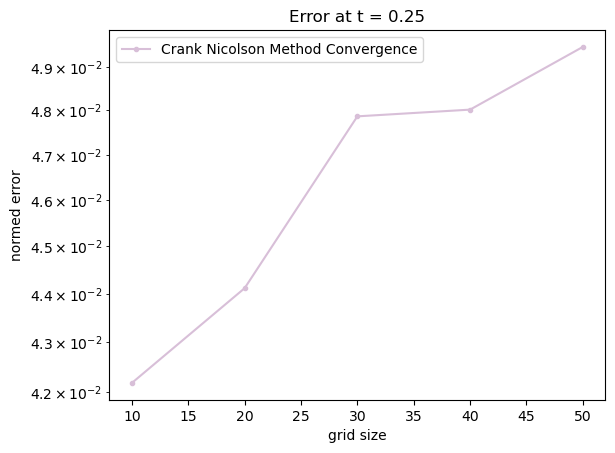

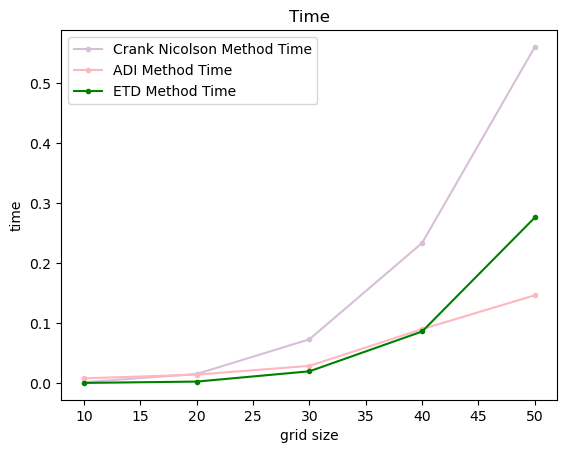

In [129]:
# plt.loglog(Ts[::2], explicit_converge[::2], '--', color = 'cornflowerblue', label = 'Explicit Method Convergence')
plt.semilogy(Ts, crank_converge, '.-', color = 'thistle', label = 'Crank Nicolson Method Convergence')
# plt.semilogy(Ts, adi_converge, '.-', color = 'lightpink', label = 'ADI Method Convergence')
# plt.semilogy(Ts, edt_converge, '.-', color = 'green', label = 'ETD Method Convergence')
# plt.semilogx(Ts, Ts**2)
plt.xlabel(r'grid size')
plt.ylabel('normed error')
plt.title(r'Error at t = 0.25')
plt.legend()
plt.show()

# plt.plot(Ts, explicit_time, '.-', color = 'cornflowerblue', label = 'Explicit Method Time')
plt.plot(Ts, crank_time, '.-', color = 'thistle', label = 'Crank Nicolson Method Time')
plt.plot(Ts, adi_time, '.-', color = 'lightpink', label = 'ADI Method Time')
plt.plot(Ts, edt_time, '.-', color = 'green', label = 'ETD Method Time')
plt.xlabel(r'grid size')
plt.ylabel('time')
plt.title('Time')
plt.legend()
plt.show()

In [97]:
# Create 3D plot
fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(221, projection='3d')
plt.suptitle(r'Solutions of $u_t = u_{xx} + u_{yy}$')

# Create empty line objects
explicit = ax1.plot_surface(X, Y, my_truth(X,Y,0), cmap = 'magma',vmax = np.max(U_explicit), vmin = np.min(U_explicit))
ax1.set_title('Explicit Method')
plt.tight_layout()

ax1.set_zlim3d([-.7,.7])

# Make update function to updata all line plots
def update(t):
    global explicit

    explicit.remove()

    explicit = ax1.plot_surface(X, Y, my_truth(X,Y,t_vals[t]), cmap = 'magma',vmax = np.max(U_explicit), vmin = np.min(U_explicit))
    
    plt.tight_layout()

    return explicit, crank, adi, edt


# Make figure
ani = FuncAnimation(fig, update, frames=range(len(t_vals)), interval=50)
ani.save(f'test_solution.mp4')

plt.close()

